In [1]:
library(torch)
library(luz)
#library(lecospectR)

In [2]:
source("./Functions/lecospectR.R")

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: compiler

Loading required package: raster

Loading required package: sp


Attaching package: ‘raster’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: hsdar

Loading required package: rgdal

Please note that rgdal will be retired during October 2023,
plan transition to sf/stars/terra functions using GDAL and PROJ
at your earliest convenience.
See https://r-spatial

In [3]:
net <- nn_module(
    "jigsaw",
     initialize = function(num_components = 695, num_levels = 8) {
      self$internal_dimension <- 256
      self$A <- nn_conv1d(
        in_channels = num_components, 
        out_channels = self$internal_dimension,
        kernel_size = 1, 
        padding = 1)

      # define the B block;
      self$B3 <- nn_sequential(
        nn_conv1d(self$internal_dimension,6,1, padding = 1), 
        nn_conv1d(6,9,3))
      self$B5 <- nn_sequential(
        nn_conv1d(self$internal_dimension,10,1, padding = 3), 
        nn_conv1d(10,9,5))
      self$B7 <- nn_sequential(
        nn_conv1d(self$internal_dimension,128,1, padding = 5), 
        nn_conv1d(128,9,7))
      self$B9 <- nn_sequential(
        nn_conv1d(self$internal_dimension,128,1, padding = 7), 
        nn_conv1d(128,9,9))

    self$B <- nn_sequential(
      nn_adaptive_avg_pool1d(
        self$internal_dimension
      ), 
      nn_flatten(), 
      nn_linear(
        in_features = 2304,# concatenated dimension
        out_features = self$internal_dimension
      ), 
      nn_dropout(p = 0.4)
      )



      #C block
      self$C <- nn_sequential(
        nn_flatten(start_dim = 2,end_dim = -1),
        nn_linear(
          in_features = 768, # A 
          out_features = 768
        ), 
        nn_relu(),
        nn_dropout(p = 0.4),
        nn_linear(
          in_features = 768, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.4),
        nn_relu()
      )

      self$D <- nn_sequential(
        nn_linear(
          in_features = 2 * self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.4),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = 8
        )
      )
    
  },

  forward = function(x) {
    x_A <- self$A(x)
    x_b3 <- self$B3(x_A)
    x_b5 <- self$B5(x_A)
    x_b7 <- self$B7(x_A)
    x_b9 <- self$B9(x_A)


    #print(paste0("A: ", dim(x_A)))
    #print(paste0("B3: ", dim(x_b3)))
    #print(paste0("B5: ", dim(x_b5)))
    #print(paste0("B7: ", dim(x_b7)))
    #print(paste0("B9: ", dim(x_b9)))

    x_B_concat <- torch_cat(tensors = list(
      x_b3, 
      x_b5, 
      x_b7, 
      x_b9
    ), dim = 3)

    x_B <- self$B(x_B_concat)
    #print(paste0("B: ", dim(x_B)))

    x_C <- self$C(x_A)
    #print(paste0("C: ", dim(x_C)))


    x_D <- self$D(
      torch_cat(
        tensors = list(
          x_B, 
          x_C
        ), dim = 2)
    )

    #class_label <- torch_argmax(x_D, dim = 2)
    #print(paste0("D: ", dim(x_D)))

    return(x_D)
  }

  
)

In [4]:
add_channel_dim <- function(img) {
   x <- img$unsqueeze(1)
   return(torch_transpose(x, 1,2))
}

In [5]:
create_variable_names <- function(start, stop){
    names <- c()
    for(i in start:stop){
        names <- append(
            names, 
            paste0("X", i))
    }

    return(names)
}

In [6]:
independent_variables <- create_variable_names(400L, 999L)

dependent_variable <- "FncGrp1" 
NUM_VARS <- length(independent_variables)
print(length(independent_variables))

[1] 600


In [7]:
# define the dataset
data_df <- read.csv(file = "Data/Ground_Validation/PFT_image_spectra/PFT_Image_SpectralLib_Clean.csv")


In [8]:

lecospec_dataset <- torch::dataset(
    name = "lecospec_image",
    initialize = function(df, transform = function(x){x}) {
        self$x <- as.matrix(
            cbind(
                df[, independent_variables], 
                get_vegetation_indices(df = df, ml_model = NULL) %>%
                    clip_outliers()
            )
        )
        self$y <- torch_tensor(
            as.matrix(
                as.integer(
                    as.factor(
                        df[, dependent_variable]
                        )
                    )
                )
            )
        self$transform <- transform
    },

    .getitem = function(i) {
        list(
            x = self$transform(torch_flatten(self$x[i,])),
            y = torch_flatten(self$y[i])$squeeze()
        )
    },

    .length = function() {
        self$y$size()[[1]]
    }
)

In [9]:
head(data_df)

,X,UID,ScanNum,sample_name,PFT,FncGrp1,Site,X398,X399,X400,⋯,X990,X991,X992,X993,X994,X995,X996,X997,X998,X999
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,BisonGulchPFTsBetula1,1,spec_1,Betula,ShrubDecid,BisonGulch,0.05814769,0.05926529,0.06028869,⋯,0.6815182,0.6811660,0.6890470,0.7040298,0.7249807,0.7507566,0.7801884,0.8121027,0.8453261,0.8786852
2,2,BisonGulchPFTsBetula1,1,spec_2,Betula,ShrubDecid,BisonGulch,0.04456014,0.04778814,0.05079318,⋯,0.6706666,0.6683159,0.6786394,0.7000307,0.7308801,0.7695067,0.8140391,0.8625739,0.9132079,0.9640378
3,3,BisonGulchPFTsBetula1,1,spec_3,Betula,ShrubDecid,BisonGulch,0.03929324,0.04265593,0.04557066,⋯,0.5152525,0.5091915,0.5178217,0.5395294,0.5726982,0.6156166,0.6663192,0.7227978,0.7830447,0.8450520
4,4,BisonGulchPFTsBetula1,1,spec_4,Betula,ShrubDecid,BisonGulch,0.13230228,0.11122692,0.09129034,⋯,0.5120581,0.5113880,0.5348292,0.5745538,0.6227243,0.6723311,0.7185860,0.7570701,0.7833644,0.7930498
5,5,BisonGulchPFTsBetula1,1,spec_5,Betula,ShrubDecid,BisonGulch,0.05211388,0.05565497,0.05878525,⋯,0.6863419,0.6680365,0.6509006,0.6344450,0.6181806,0.6017555,0.5851848,0.5685449,0.5519121,0.5353626
6,6,BisonGulchPFTsBetula1,1,spec_6,Betula,ShrubDecid,BisonGulch,0.06955397,0.06788242,0.06631141,⋯,0.7354495,0.7371508,0.7445194,0.7567953,0.7732173,0.7930235,0.8154512,0.8397375,0.8651196,0.8908347


In [10]:
num_per_pft <- 300
train_test_data <- create_patch_balanced_sample(
    data_df,
    test_count = 20,
    train_count = NULL,
    verbose = FALSE
    )

split_2_train <- create_patch_balanced_sample(
    train_test_data$remainder,
    test_count = num_per_pft,
    train_count = 1000,
    verbose = FALSE
    )

In [11]:
print(names(split_2_train))

[1] "selection"         "remainder"         "samples_per_patch"
[4] "samples_per_class"


In [12]:
print(split_2_train$selection)

      X                   UID ScanNum sample_name    PFT        FncGrp1
5     5 BisonGulchPFTsBetula1       1      spec_5 Betula     ShrubDecid
17   17 BisonGulchPFTsBetula1       1     spec_17 Betula     ShrubDecid
14   14 BisonGulchPFTsBetula1       1     spec_14 Betula     ShrubDecid
13   13 BisonGulchPFTsBetula1       1     spec_13 Betula     ShrubDecid
9     9 BisonGulchPFTsBetula1       1      spec_9 Betula     ShrubDecid
8     8 BisonGulchPFTsBetula1       1      spec_8 Betula     ShrubDecid
3     3 BisonGulchPFTsBetula1       1      spec_3 Betula     ShrubDecid
4     4 BisonGulchPFTsBetula1       1      spec_4 Betula     ShrubDecid
2     2 BisonGulchPFTsBetula1       1      spec_2 Betula     ShrubDecid
18   18 BisonGulchPFTsBetula1       1     spec_18 Betula     ShrubDecid
21   21 BisonGulchPFTsBetula1       1     spec_21 Betula     ShrubDecid
22   22 BisonGulchPFTsBetula1       1     spec_22 Betula     ShrubDecid
54   54 BisonGulchPFTsBetula2       2     spec_29 Betula     Shr

In [13]:
train_indices <- sample(1:nrow(data_df), 250)
train_ds <- lecospec_dataset(
    split_2_train$selection,
    transform = add_channel_dim
    )
valid_ds <- lecospec_dataset(
    train_test_data$selection, 
    transform = add_channel_dim
    )

length(train_ds)
length(valid_ds)

[1] 2222

[1] 160

In [14]:
# create a dataloader
test_dl <- torch::dataloader(
    valid_ds,
    batch_size = 80,
    shuffle = FALSE
)

train_dl <- torch::dataloader(
    train_ds,
    batch_size = 240,
    shuffle = TRUE
)

In [15]:
batch <- dataloader_make_iter(train_dl) %>% dataloader_next()
print(dim(batch$x))
print(dim(batch$y))

[1] 240 695   1
[1] 240


In [16]:
print(batch$x$shape)

[1] 240 695   1


In [17]:
print(batch$y$shape)

[1] 240


In [18]:
model <- net()
model(batch$x)


torch_tensor
-0.7830 -1.5121 -0.5867  0.1119  0.9417 -2.7318 -0.8972  0.6796
-0.3109 -1.1010 -0.1402 -0.2935 -0.2348 -0.7466 -0.3739  0.9318
 0.4777 -1.1553  0.9532 -0.8117  0.6881 -0.8753 -0.0878  0.7978
-0.3122 -0.2057 -0.0463 -0.2097 -0.6508 -0.9387  0.1002  2.0367
 0.5026 -1.0105  0.6591  0.2364 -0.1095 -1.2761  0.6022  1.2990
 0.7890 -0.5259 -1.2169  0.8855  1.5452 -0.2202  0.6993  0.9117
-0.2358 -0.2555  0.2196  0.8676 -1.4084 -0.2196 -0.1454  0.3802
 0.7032 -1.0133  0.1738  0.8916  0.3121 -1.4054  0.2881  0.6476
 0.9394  1.1254  0.6495 -0.8381  0.2697 -1.0200  0.1633  0.9364
-1.4614 -0.2151 -0.5066  0.5194 -0.1949  0.1111  0.2704  0.8965
-0.1719 -0.6554 -0.4049 -1.2021  1.0064  0.0725  0.2903  1.5116
-0.1899 -1.5458  0.2998 -0.0413 -0.2838 -0.9681  0.9871  0.6761
 0.1875  0.2625  0.5135 -0.4733  0.7581 -0.1570  0.0413  1.2495
-1.8267  1.2684 -0.9930 -0.5971  0.4838 -0.0055 -0.8394  0.7187
-2.0408 -1.2508 -0.1796  0.1110  0.4194 -0.3822 -0.3434 -0.0076
-0.2667  0.3253 -0.8301 -0.

In [19]:
batch$y

torch_tensor
 2
 5
 7
 2
 1
 4
 3
 3
 2
 4
 8
 3
 5
 2
 1
 1
 8
 2
 2
 2
 7
 8
 8
 3
 7
 1
 1
 2
 7
 7
... [the output was truncated (use n=-1 to disable)]
[ CPULongType{240} ]

In [20]:
print_callback <- luz_callback(
  name = "print_callback",
  initialize = function(message) {
    self$message <- message
  },
  on_train_batch_end = function() {
    cat("Iteration ", ctx$iter, "\n")
  },
  on_epoch_end = function() {
    cat(self$message, "\n")
  }
)

In [21]:
net_fitted <- net %>%
  setup(
    loss = nn_cross_entropy_loss(),
    optimizer = optim_adam,
    metrics = list(
      luz::luz_metric_accuracy()
    )
  ) %>%
  set_opt_hparams(lr = 0.001) %>% 
  fit(
    train_dl, 
    epochs = 1000, 
    valid_data = test_dl,
    callbacks = list(
      print_callback("Training Complete")
    )
    )

Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3 
Iteration  4 
Iteration  5 
Iteration  6 
Iteration  7 
Iteration  8 
Iteration  9 
Iteration  10 
Training Complete 
Iteration  1 
Iteration  2 
Iteration  3

In [22]:
net_fitted

A `luz_module_fitted`
── Time ────────────────────────────────────────────────────────────────────────
• Total time: 1h 24m 21.2s
• Avg time per training epoch: 4.9s

── Results ─────────────────────────────────────────────────────────────────────
Metrics observed in the last epoch.

ℹ Training:
loss: 0.1743
acc: 0.9343

── Model ───────────────────────────────────────────────────────────────────────
An `nn_module` containing 1,778,080 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• A: <nn_conv1d> #178,176 parameters
• B3: <nn_sequential> #1,713 parameters
• B5: <nn_sequential> #3,029 parameters
• B7: <nn_sequential> #40,969 parameters
• B9: <nn_sequential> #43,273 parameters
• B: <nn_sequential> #590,080 parameters
• C: <nn_sequential> #787,456 parameters
• D: <nn_sequential> #133,384 parameters

In [23]:
predict(net_fitted,newdata = batch$x)

torch_tensor
 -18.8555   36.5121  -84.0932  -42.2451   10.8913   -9.1463   -2.6979   18.0444
 -41.1337   -8.2265  -61.2675  -67.4783   25.7559  -10.8653   10.4046  -10.5077
 -49.5474  -27.4778  -57.2592  -55.7738   16.9439  -57.5252   42.5938    5.9872
 -27.2307   24.6832  -63.4588  -43.5188   15.9194   -8.8824   11.2337    4.6192
  18.2024  -21.0200  -17.3641   -1.6665  -21.2380  -11.1374   -2.9997    7.1516
  10.7850   17.6663    1.5234   35.0903  -25.1954  -56.0769  -44.5253  -23.5378
  -1.8078  -26.3977   62.2631   28.9805  -21.5634  -59.4973  -53.8595   13.9665
   4.4140  -22.8059    8.7455  -15.0914   -2.9132    6.2502  -12.9079    1.2157
 -21.6508   39.7293  -87.3838  -30.9298   20.0714  -11.8005  -16.0405   -1.2731
  16.6210    7.6720   25.3077   53.4866  -56.3387  -69.0359  -63.8662  -14.5279
   3.5144   16.4945  -57.6335  -30.9870  -12.5270  -25.6121   15.1971   21.9937
  -3.1153  -17.9167   22.4085   -3.7996   -2.9350  -13.8783  -18.7750   10.8049
 -45.4530    0.1562  -74.49

## Next

Need to define the correct nueral net architecture, and then the training loop should work as intended.  This is likely some kind of U-Net from a paper.  

Just a matter of finding the correct one and plugging the layers into the model above.  

Hopefully that works directly

In [24]:
preds <- predict(net_fitted, test_dl)

List of 138
 $ line                            :List of 6
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ lineend      : chr "butt"
  ..$ arrow        : logi FALSE
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_line" "element"
 $ rect                            :List of 5
  ..$ fill         : chr "white"
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_rect" "element"
 $ text                            :List of 11
  ..$ family       : chr ""
  ..$ face         : chr "plain"
  ..$ colour       : chr "black"
  ..$ size         : num 11
  ..$ hjust        : num 0.5
  ..$ vjust        : num 0.5
  ..$ angle        : num 0
  ..$ lineheight   : num 0.9
  ..$ margin       : 'margin' num [1:4] 0points 0points 0points 0points
  .. ..- attr(*, "unit")= int 8
  ..$ debug        : logi FALSE
  ..$ inherit.blank: l

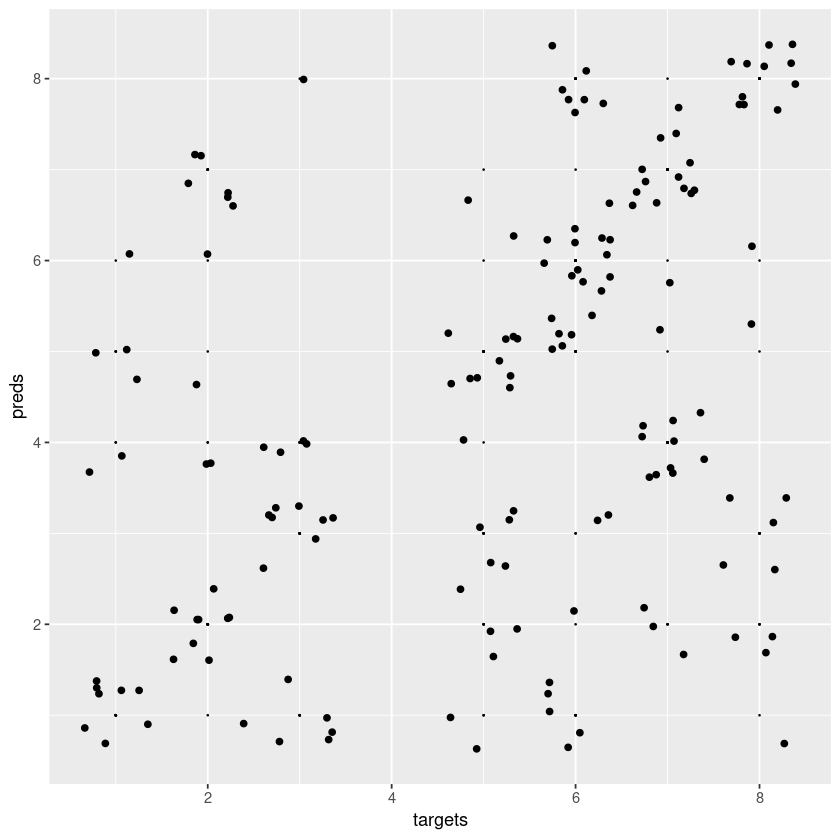

In [25]:
#test_dl <- dataloader(valid_ds, batch_size = 5000)
targets <- (test_dl %>% dataloader_make_iter() %>% dataloader_next())$y %>% as.numeric()

y_pred <- torch_argmax(preds, dim = 2) %>% as.numeric()
df <- data.frame(preds = y_pred, targets = targets)
#library(ggplot2)

#print(preds)


ggplot(df, aes(x = targets, y = preds)) +
  geom_point(size = 0.1) +
  geom_jitter()
  theme_classic() +
  xlab("true correlations") +
  ylab("model predictions")

#plot(y_pred, targets)


In [26]:
df$preds %>% as.factor() %>% levels()

[1] "1" "2" "3" "4" "5" "6" "7" "8"

In [27]:
df$targets %>% as.factor() %>% levels()

[1] "1" "2" "3" "5" "6" "7" "8"

In [28]:
target_f <- df$targets %>% as.factor()
levels(target_f) <- c(levels(target_f), '4')

In [31]:
results_cm <- caret::confusionMatrix(
    df$preds %>% as.factor(),
    target_f
)

write(x = rjson::toJSON(results_cm), file = "jigsaw_results_confusion.txt")

results_cm

Warning message in confusionMatrix.default(df$preds %>% as.factor(), target_f):
“Levels are not in the same order for reference and data. Refactoring data to match.”


Confusion Matrix and Statistics

          Reference
Prediction  1  2  3  5  6  7  8  4
         1  8  1  5  2  5  0  1  0
         2  0  9  0  4  1  3  3  0
         3  0  0  8  5  2  0  5  0
         5  3  1  0 10  6  1  1  0
         6  1  1  0  1 12  1  1  0
         7  0  6  0  1  1 12  0  0
         8  0  0  1  0  7  1 11  0
         4  2  2  4  1  0 10  0  0

Overall Statistics
                                         
               Accuracy : 0.4375         
                 95% CI : (0.3593, 0.518)
    No Information Rate : 0.2125         
    P-Value [Acc > NIR] : 1.513e-10      
                                         
                  Kappa : 0.3579         
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 5 Class: 6 Class: 7
Sensitivity            0.5714  0.45000   0.4444   0.4167   0.3529   0.4286
Specificity            0.9041  0.92143   0.9155   0.9118   0.

In [ ]:
luz_save(
    obj = net_fitted,
    path = "./dl_jigsaw_v5.dat"
    )